In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank")
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank


In [2]:
!apt-get install tesseract-ocr -qq
!pip install pytesseract opencv-python-headless jiwer datasets pillow pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.6 MB/s eta 0:00:00


In [4]:
from datasets import load_dataset
import pandas as pd
import os

os.makedirs("results/figures", exist_ok=True)

ds = load_dataset("lmms-lab/DocVQA", "DocVQA", split="validation[:300]")

def complexity(answer):
    a = answer[0] if answer else ""
    words = len(a.split())
    if words <= 2:   return 'simple'
    elif words <= 6: return 'medium'
    else:            return 'complex'

meta = []
for i in range(len(ds)):
    s = ds[i]
    meta.append({
        'id':            i,
        'question_id':   s['questionId'],
        'question':      s['question'],
        'ground_truth':  s['answers'][0] if s['answers'] else '',
        'question_type': s['question_types'][0] if s['question_types'] else 'unknown',
        'complexity':    complexity(s['answers'])
    })

df_meta = pd.DataFrame(meta)
df_meta.to_csv("results/metadata.csv", index=False)
print("metadata.csv created:", len(df_meta), "rows")
print(df_meta['complexity'].value_counts())

metadata.csv created: 300 rows
complexity
simple     201
medium      92
complex      7
Name: count, dtype: int64


In [5]:

import cv2
import numpy as np
from PIL import Image

def preprocess_image(pil_img):
    """Deskew + denoise + binarize for better OCR accuracy."""
    # convert to grayscale numpy
    img = np.array(pil_img.convert("L"))

    # denoise
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # binarize with Otsu threshold
    _, img = cv2.threshold(img, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return Image.fromarray(img)


def answer_in_text(ocr_text, ground_truth):
    """Check if ground truth answer appears in OCR output."""
    return str(ground_truth).lower().strip() in ocr_text.lower()

In [6]:
# ─── CELL 5: run OCR on all 300 samples ─────────────────────────────────
import pytesseract
import time

results = []

for i in range(len(ds)):
    sample  = ds[i]
    img     = sample['image']
    gt      = df_meta.loc[i, 'ground_truth']
    question = df_meta.loc[i, 'question']

    # --- raw OCR ---
    t0 = time.perf_counter()
    raw_text = pytesseract.image_to_string(img)
    t_raw = time.perf_counter() - t0

    # --- preprocessed OCR ---
    t0 = time.perf_counter()
    proc_text = pytesseract.image_to_string(preprocess_image(img))
    t_proc = time.perf_counter() - t0

    # --- check if answer found ---
    raw_correct  = answer_in_text(raw_text,  gt)
    proc_correct = answer_in_text(proc_text, gt)

    results.append({
        'id':               i,
        'ground_truth':     gt,
        'question_type':    df_meta.loc[i, 'question_type'],
        'complexity':       df_meta.loc[i, 'complexity'],
        'raw_ocr_text':     raw_text,
        'proc_ocr_text':    proc_text,
        'raw_correct':      raw_correct,
        'proc_correct':     proc_correct,
        'raw_time':         round(t_raw,  3),
        'proc_time':        round(t_proc, 3),
    })

    if i % 50 == 0:
        print(f"Done {i}/300 — raw acc so far: "
              f"{sum(r['raw_correct'] for r in results)}/{len(results)}")

print("\nDone!")

Done 0/300 — raw acc so far: 0/1
Done 50/300 — raw acc so far: 30/51
Done 100/300 — raw acc so far: 59/101
Done 150/300 — raw acc so far: 98/151
Done 200/300 — raw acc so far: 130/201
Done 250/300 — raw acc so far: 164/251

Done!


In [7]:
df_ocr = pd.DataFrame(results)

# drop full text columns for the summary CSV — keep separate
df_ocr.drop(columns=['raw_ocr_text', 'proc_ocr_text']).to_csv(
    "results/ocr_results.csv", index=False)

# save full text separately for notebook 4 analysis
df_ocr.to_csv("results/ocr_results_full.csv", index=False)

print("Saved.")
print(df_ocr[['raw_correct','proc_correct']].mean().round(3))

Saved.
raw_correct     0.647
proc_correct    0.667
dtype: float64



Accuracy by complexity:
            raw_correct  proc_correct
complexity                           
complex           0.143         0.143
medium            0.652         0.641
simple            0.662         0.697


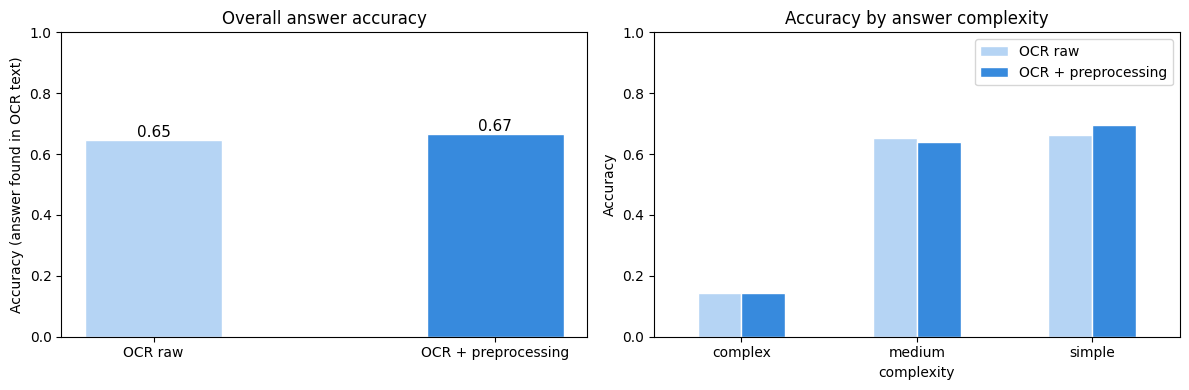

Saved to results/figures/ocr_accuracy.png


In [8]:
# ─── CELL 7: quick summary plot ─────────────────────────────────────────
import matplotlib.pyplot as plt

# accuracy by complexity
groups = df_ocr.groupby('complexity')[['raw_correct','proc_correct']].mean()
print("\nAccuracy by complexity:")
print(groups.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# plot 1 — overall accuracy
methods = ['OCR raw', 'OCR + preprocessing']
scores  = [df_ocr['raw_correct'].mean(), df_ocr['proc_correct'].mean()]
axes[0].bar(methods, scores, color=['#B5D4F4', '#378ADD'], width=0.4, edgecolor='white')
axes[0].set_title("Overall answer accuracy")
axes[0].set_ylabel("Accuracy (answer found in OCR text)")
axes[0].set_ylim(0, 1)
for j, (m, s) in enumerate(zip(methods, scores)):
    axes[0].text(j, s + 0.01, f"{s:.2f}", ha='center', fontsize=11)

# plot 2 — accuracy by complexity
groups.plot(kind='bar', ax=axes[1], color=['#B5D4F4','#378ADD'],
            edgecolor='white')
axes[1].set_title("Accuracy by answer complexity")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['OCR raw', 'OCR + preprocessing'])

plt.tight_layout()
plt.savefig("results/figures/ocr_accuracy.png", dpi=150)
plt.show()
print("Saved to results/figures/ocr_accuracy.png")

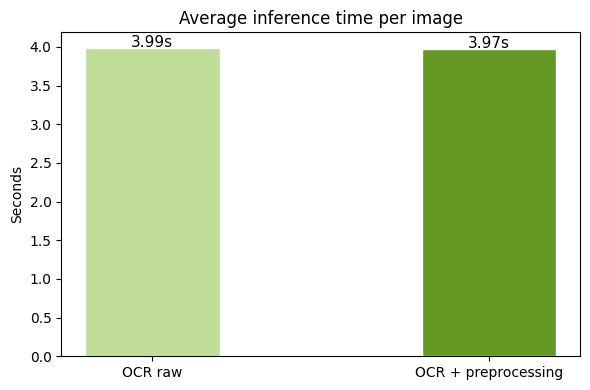

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
times = [df_ocr['raw_time'].mean(), df_ocr['proc_time'].mean()]
ax.bar(['OCR raw', 'OCR + preprocessing'], times,
       color=['#C0DD97', '#639922'], width=0.4, edgecolor='white')
ax.set_title("Average inference time per image")
ax.set_ylabel("Seconds")
for j, t in enumerate(times):
    ax.text(j, t + 0.01, f"{t:.2f}s", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("results/figures/ocr_runtime.png", dpi=150)
plt.show()

In [11]:
!git config --global user.email "chaitanyamhetre97@email.com"
!git config --global user.name "chaitanyamhetre"

!git add .
!git commit -m "Add notebook 02 results — OCR baseline 65-67% accuracy"
!git push

[main dd1e8b2] Add notebook 02 results — OCR baseline 65-67% accuracy
 6 files changed, 36500 insertions(+)
 create mode 100644 results/figures/.gitkeep
 create mode 100644 results/figures/ocr_accuracy.png
 create mode 100644 results/figures/ocr_runtime.png
 create mode 100644 results/metadata.csv
 create mode 100644 results/ocr_results.csv
 create mode 100644 results/ocr_results_full.csv
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (10/10), 161.74 KiB | 2.89 MiB/s, done.
Total 10 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/chaitanyamhetre/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank.git
   2591961..dd1e8b2  main -> main
